In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# 1
df1 = pd.DataFrame({'name' : ['mahesh','kiran','suresh','sumit','ramesh','swapnil','swati'],'age':[23,25,28,26,27,30,29],'salary':[10000,12000,15000,14000,25000,20000,26000]})

print(df1)

      name  age  salary
0   mahesh   23   10000
1    kiran   25   12000
2   suresh   28   15000
3    sumit   26   14000
4   ramesh   27   25000
5  swapnil   30   20000
6    swati   29   26000


In [3]:
#2
print(df1['salary'].max())

26000


In [4]:
#3
print(df1['salary'].min())

10000


In [5]:
#4 sorting age in descending order

print("sorted\n",df1.sort_values(by='age',ascending = False))
print()
print("original\n",df1)

sorted
       name  age  salary
5  swapnil   30   20000
6    swati   29   26000
2   suresh   28   15000
4   ramesh   27   25000
3    sumit   26   14000
1    kiran   25   12000
0   mahesh   23   10000

original
       name  age  salary
0   mahesh   23   10000
1    kiran   25   12000
2   suresh   28   15000
3    sumit   26   14000
4   ramesh   27   25000
5  swapnil   30   20000
6    swati   29   26000


{1: 7, 3: 3, 4: 2, 5: 5, 6: 8, 7: 5, 8: 6, 9: 3, 10: 7, 11: 7, 12: 4, 13: 6, 14: 11, 15: 5, 16: 6, 17: 3, 18: 6, 19: 6}


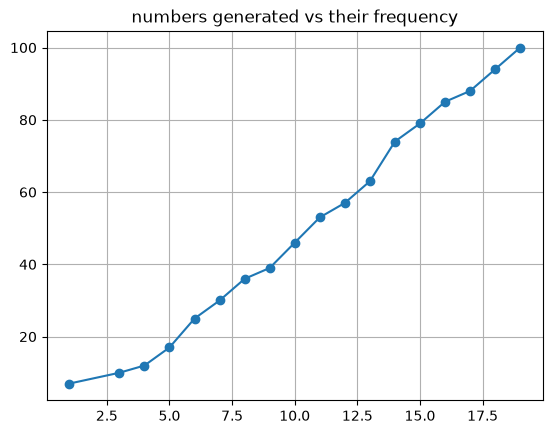

In [6]:
# Write a program to plot the ogive of random data from 1 to 20
data = []
for i in range(0,100):
    x = np.random.randint(1,20)
    data.append(x)

freq = {}

for i in range(0,len(data)):
    if data[i] in freq:
        freq[data[i]] += 1 
    else:
        freq[data[i]] = 1

freq = dict(sorted(freq.items()))  # sorted dict based on keys

print(freq)

x = []
y = []


cum = 0

for i,j in freq.items() :
    x.append(i) # key thats numbers
    cum += j # add prev frequency giving a less than cumulative distribution
    y.append(cum) # value thats the frequency

plt.title('numbers generated vs their frequency')
plt.plot(x,y,marker='o')
plt.grid(True)
plt.show()
     
    
    

[25 10 18  6 22  8  7 16 18  7 17 10 12  5 13 22 16  8 11 10 14 26  8 30
 23  1 25 15 30 13 12 19  2 26 30  8 18 15 15  3 10 12 29 20 13 19  3  8
 25  7]


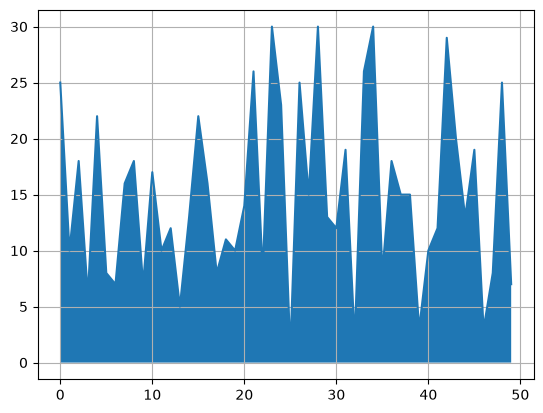

In [7]:
# 6. Write a program to plot the area chart of the data from 1 to 30. 

iters = 50

data = np.random.randint(1,31,iters)  # generate iters times random values between 1-30 inclusive

# data = np.sort(data)

print(data)

x = range(0,iters)

y = data

plt.plot(x,y)

plt.grid(True)

plt.fill_between(x,y)

plt.show()




In [8]:
df2 = pd.DataFrame({
    'name': ['Ramesh', 'Vedika', 'Harun', 'Prasad'],
    'maths': [78, 76, 84, 67],
    'english': [67, 75, 59, 72],
    'science': [56, 47, 60, 54]
})

print(df2,'\n\n------------------------------------')

# 8. Access the element in the 1st row in the 3rd column. 

print(df2.iloc[1,3])  # first row third column

print('------------------------------------')

# 9. Access all the element in 3rd column. 
print(df2.iloc[:,3])

print('------------------------------------')


# 10. Access elements of 2nd and 3rd row from 1st and 2nd column. 

# print(df2.iloc[1:3])

print(df2.iloc[2:4,1:3])  # here 4 and 3 not included so 





     name  maths  english  science
0  Ramesh     78       67       56
1  Vedika     76       75       47
2   Harun     84       59       60
3  Prasad     67       72       54 

------------------------------------
47
------------------------------------
0    56
1    47
2    60
3    54
Name: science, dtype: int64
------------------------------------
   maths  english
2     84       59
3     67       72


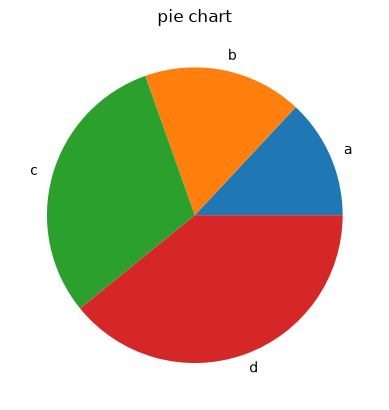

In [9]:
# 11. Write a program to plot a pie chart of values=[3,4,7,9] and categories=[‘A’, ‘B’, ‘C’, ‘D’]. 
values = [3,4,7,9]
cat = ['a','b','c','d']

plt.pie(values,labels = cat)
plt.title('pie chart')
plt.show()

In [10]:
# helper: mathematical position -> Python index def at(pos): return x[pos - 1]
# very imp ! memorise by heart for future conversions 
def at(pos, x): 
    n = len(x) 
    if pos < 1: 
        pos = 1 
    elif pos > n: 
        pos = n 
    return x[pos - 1]

In [11]:
# 12. Write the code for outlier removal from scratch.
# we use IQR method if x<lower or > upper then outlier



data = [ 4, 7, 10, 14, 36, 16, 18, 20, 67, 22, 2]

data = sorted(data)

def percentile(p,x:list):
    x = sorted(x)
    n = len(x)

    v1 = (p/100)*n

    if(v1 % 1 != 0):
        # means its some point (decimal) value
        pos = int(v1)
        
        return at(pos,x)
    else :
        # if v1 is integer
        # enforced interger if 7.0 => 7
        v1 = int(v1)
        
        i1 = v1
        i2 = v1+1
        
        ans = (at(i1,x) + at(i2,x)) / 2
        return ans

def IQR(x:list):
    q1 = percentile(25,x)
    q3 = percentile(75,x)
    return q3 - q1

lower = percentile(25,data) - IQR(data)*1.5
upper = percentile(75,data) + IQR(data)*1.5

new_data = []

outliers = []

for i in data:
    if(lower <= i and upper >= i) :
        new_data.append(i)
    else:
        outliers.append(i)

print(new_data)
print(outliers)
    



[2, 4, 7, 10, 14, 16, 18, 20, 22, 36]
[67]


In [12]:
''' 14. Write the code of Finding Covariance from given data 
15. X= [2, 4, 6, 8, 10] , Y= [1, 3, 5, 7, 9] '''

X= [2, 4, 6, 8, 10]
Y= [1, 3, 5, 7, 9]

def covariance(x:list,y:list):
    m1 = len(x)
    m2 = len(y)
    
    xm = sum(x) / m1
    ym = sum(y) / m2

    summ = 0

    for i in range(0,m1):
        t1 = x[i] - xm
        t2 = y[i] - ym

        summ = summ + (t1*t2)


    return summ/(m1-1)

print(covariance(X,Y))

    



10.0


In [13]:
# 16
def mean(x:list):
    return (sum(x)/len(x))

print(mean( [10, 20, 30, 40, 50]))

30.0


In [14]:
# 17. Using NumPy, calculate the mean and median of [12, 15, 18, 20, 25, 30]. 
data =  [12, 15, 18, 20, 25, 30]

print('mean : ',np.mean(data))
print('median : ',np.median(data))




mean :  20.0
median :  19.0


In [15]:
# 18 18. Write a Python program from scratch to find the median of 

def median(x:list):
    x = sorted(x)

    if(len(x) % 2 == 1):
        mi = (len(x) // 2)
        return x[mi]
    else :
        mi2 = len(x) // 2
        mi1 = mi2-1
        

        avg = (x[mi1] + x[mi2])/2

        return avg
    


print(median([15, 10, 20, 25, 30])) 

20


In [16]:
'''19. Using Pandas, calculate the mean, median, and mode of a DataFrame column named
Income. '''

df = pd.DataFrame({'name' : ['mahesh','kiran','mimi','sumit','ramesh','swapnil','swati'],'age':[23,25,10,26,27,30,29],'income':[12000,12000,20000,14000,25000,20000,26000]})


print(df['income'].mean())

print()

print(df['income'].median())

print()

print(df['income'].mode()[0]) # mode can returns multiple values 


18428.571428571428

20000.0

12000


In [17]:
''' 20. Write a Python program from scratch to find the mode of [10, 20, 20, 30, 40, 20, 50]. 
'''
data =  [10, 20, 20, 30, 40,40, 20, 50]


def mode2(x:list):
    ans = max(set(x),key=x.count)
    return ans

print(mode2(data))




20


In [18]:
''' 21. Using NumPy, calculate the range of [15, 20, 25, 30, 45, 50]. 
'''

data =  [15, 20, 25, 30, 45, 50]

ran = np.max(data) - np.min(data)

print(ran)


35


In [19]:
def pop_variance(x:list):

    n = len(X)
    
    xm = sum(x) / n

    summ = 0

    for i in range(0,n):
        t1 = (x[i] - xm)**2

        summ = summ + t1

    return summ/n

print(pop_variance([10, 12, 15,18, 20]))
        

    
    

13.6


In [20]:
# 23. Using NumPy, calculate the variance and standard deviation of [10, 12, 15, 18, 20]. 


data = [10, 12, 15, 18, 20]

print(np.var(data))
print()
print(np.std(data))

13.6

3.687817782917155


In [21]:
''' 24. Write a Python program from scratch to calculate the covariance between X =
[10,20,30,40,50] and Y = [15,25,35,45,55].  '''

X =[10,20,30,40,50]
Y = [15,25,35,45,55]

print(covariance(X,Y)) # defined the func above


250.0


In [22]:
#  25. Using Pandas, calculate the correlation coefficient between Income and Loan_Amount. 

# 1. Create the dataset
data = {
    'Income': [35000, 45000, 50000, 65000, 80000, 110000],
    'Loan_Amount': [100000, 140000, 150000, 200000, 240000, 310000]
}

# 2. Load into a DataFrame
df = pd.DataFrame(data)

print( df['Income'].corr(df['Loan_Amount']) )

print()

# print(df['Loan_Amount'].corr(df['Income']))

0.9958781319086513



In [23]:
'''26. Write a Python program from scratch to calculate Pearson's correlation coefficient for two
numerical lists. '''

def variance(x:list):

    n = len(x)
    
    xm = sum(x) / n

    summ = 0

    for i in range(0,n):
        t1 = (x[i] - xm)**2

        summ = summ + t1

    return summ/(n-1)

def standard_dev(x:list):
    var = variance(x)
    return(var ** 0.5)


def covariance(x:list,y:list):
    m1 = len(x)
    m2 = len(y)
    
    xm = sum(x) / m1
    ym = sum(y) / m2

    summ = 0

    for i in range(0,m1):
        t1 = x[i] - xm
        t2 = y[i] - ym

        summ = summ + (t1*t2)


    return summ/(m1-1)

##############################
x = [10,20,30,40,50,100]
y = [11,22,33,44,55,111]

numer = covariance(x,y)

deno = standard_dev(x) * standard_dev(y)

correal = numer/deno

print(correal)


    

0.9999869478108211


   Income  Loan_Amount
0   35000       100000
1   45000       140000
2   50000       150000
3   65000       200000
4   80000       240000
5  110000       310000


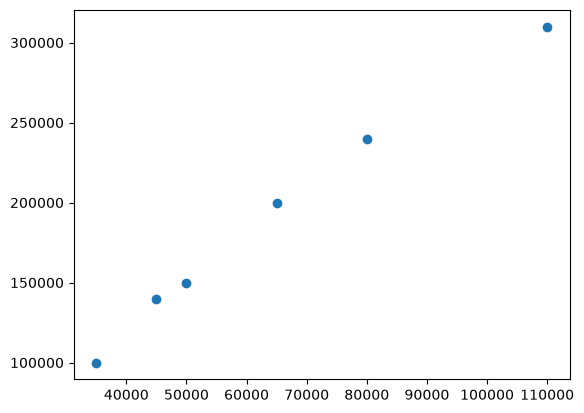

In [24]:
''' 27. Using Matplotlib, create a scatter plot to show the relationship between Income and
Loan_Amount. '''

print(df)

plt.scatter(df['Income'],df['Loan_Amount'])
plt.show()


In [25]:
''' 28. Use Python's random library to simulate 1,000 coin tosses and calculate the experimental
probability of getting Heads. '''

toss = np.random.randint(0,2,1000) #0 or 1 1000 times

toss = list(toss) # converted to normal list for simplicity
 
# let 0 be tails 1 be heads 

print('tails : ', toss.count(0)/1000)

print('heads : ',toss.count(1)/1000)

tails :  0.501
heads :  0.499


In [26]:
''' 29 Use Python's random library to simulate 10,000 die rolls and calculate the probability of
obtaining a 6 '''

times = 10000

roll = np.random.randint(1,7,times)

roll = list(roll) # converted to normal list for simplicity
 
print('6 freq : ', roll.count(6)/times)



6 freq :  0.1723


In [33]:
''' 31. Using Python collections, count the occurrence of each outcome in
['H','T','H','H','T','T','H','T'] and calculate their probabilities.  '''

from collections import Counter as cc

outcomes = ['H','T','H','H','T','T','H','T']

countt = dict(cc(outcomes))

proh = countt['H'] / len(outcomes)
prot = countt['T'] / len(outcomes)

print(proh)
print(prot)



0.5
0.5


In [28]:
''' 30. Write a Python program to demonstrate the complement rule using a coin-toss experiment. 
32. Write a Python program to verify that P(A) + P(Aᶜ) = 1 using a random experiment '''

times = 1000

toss = np.random.randint(0,2,times)

toss = list(toss) # converted to normal list for simplicity
 
# let 0 be tails 1 be heads 

pac =  toss.count(0)/times
pa =  toss.count(1)/times

print('tails P(Ac) : ',pac)

print('heads P(A) : ',pa)

print('P(Ac) + P(A) : ',pac+pa)


tails P(Ac) :  0.531
heads P(A) :  0.469
P(Ac) + P(A) :  1.0


In [36]:
''' 33. Simulate two independent coin tosses and calculate the experimental probability of
obtaining two Heads. '''

times = 50000

coin1 = np.random.randint(0,2,times)
coin2 = np.random.randint(0,2,times)

hh_freq = 0

for i in range(0,times):
    if(coin1[i] == coin2[i] == 1):
        hh_freq += 1
        # add if both coin1 and coin2 are 1 or head at same toss number

prob = hh_freq/times

print(prob)
        
        

0.24884
